In [1]:
import kaggle

!kaggle competitions download -c house-prices-advanced-regression-techniques


  0%|          | 0.00/199k [00:00<?, ?B/s]
100%|##########| 199k/199k [00:00<00:00, 2.62MB/s]


In [2]:
import zipfile

with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [118]:
df_train = pd.read_csv("train.csv", index_col="Id")
df_test = pd.read_csv("test.csv", index_col="Id")
df_train.head(30)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


In [120]:
test_length = len(df_test)
df_test.shape

(1459, 79)

In [121]:
df_train.shape

(1460, 80)

In [122]:
y_train = df_train["SalePrice"]
df_train.drop(columns="SalePrice", inplace=True)
df = pd.concat([df_train, df_test])

In [123]:
def houses_preprocessing(df):
    df1 = pd.get_dummies(df,
                         columns=["MSSubClass", 'Alley', "BsmtFinType1", "BsmtFinType2", "GarageType", "GarageFinish",
                                  "MiscFeature", "Fence"])

    encoding_dict = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Mn ": 2, "No": 1, "Po": 1, pd.NA: 0}

    df1 = df1.replace(encoding_dict)

    df_encoded = pd.get_dummies(df1)
    return df_encoded

In [124]:
df = houses_preprocessing(df)
X_train = df.iloc[:-test_length, :]
X_test = df.iloc[-test_length:, :]
X_train.head(10)

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,7,5,2003,2003,196.0,4,3,4,...,0,0,0,1,0,0,0,0,1,0
2,80.0,9600,6,8,1976,1976,0.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0
3,68.0,11250,7,5,2001,2002,162.0,4,3,4,...,0,0,0,1,0,0,0,0,1,0
4,60.0,9550,7,5,1915,1970,0.0,3,3,3,...,0,0,0,1,1,0,0,0,0,0
5,84.0,14260,8,5,2000,2000,350.0,4,3,4,...,0,0,0,1,0,0,0,0,1,0
6,85.0,14115,5,5,1993,1995,0.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0
7,75.0,10084,8,5,2004,2005,186.0,4,3,5,...,0,0,0,1,0,0,0,0,1,0
8,NaN,10382,7,6,1973,1973,240.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0
9,51.0,6120,7,5,1931,1950,0.0,3,3,3,...,0,0,0,1,1,0,0,0,0,0


In [125]:
X_test.head(10)

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1461,80.0,11622,5,6,1961,1961,0.0,3,3,3,...,0,0,0,1,0,0,0,0,1,0
1462,81.0,14267,6,6,1958,1958,108.0,3,3,3,...,0,0,0,1,0,0,0,0,1,0
1463,74.0,13830,5,5,1997,1998,0.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0
1464,78.0,9978,6,6,1998,1998,20.0,3,3,3,...,0,0,0,1,0,0,0,0,1,0
1465,43.0,5005,8,5,1992,1992,0.0,4,3,4,...,0,0,0,1,0,0,0,0,1,0
1466,75.0,10000,6,5,1993,1994,0.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0
1467,NaN,7980,6,7,1992,2007,0.0,3,4,4,...,0,0,0,1,0,0,0,0,1,0
1468,63.0,8402,6,5,1998,1998,0.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0
1469,85.0,10176,7,5,1990,1990,0.0,3,3,4,...,0,0,0,1,0,0,0,0,1,0


In [102]:
def hyperparameter_tuning(X_train, y_train):
    param_tuning = {
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5, 7, 10],
        'min_child_weight': [1, 3, 5],
        'n_estimators': [500, 1000],
        'objective': ['reg:squarederror']
    }

    xgb_model = xgb.XGBRegressor()

    gsearch = GridSearchCV(estimator=xgb_model,
                           param_grid=param_tuning,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           n_jobs=1,
                           verbose=3)

    gsearch.fit(X_train, y_train)

    return gsearch.best_params_

In [103]:
hyperparameter_tuning(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, objective=reg:squarederror;, score=-623756122.099 total time=   1.1s
[CV 2/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, objective=reg:squarederror;, score=-1013397962.208 total time=   0.9s
[CV 3/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, objective=reg:squarederror;, score=-986252970.466 total time=   0.8s
[CV 4/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, objective=reg:squarederror;, score=-727195437.520 total time=   0.8s
[CV 5/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=500, objective=reg:squarederror;, score=-1035493294.019 total time=   0.8s
[CV 1/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=1000, objective=reg:squarederror;, score=-554383752.466 total time=   1.8s
[CV 2/5] END lear

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 1000,
 'objective': 'reg:squarederror'}

In [113]:
X_subtrain, X_subtest, y_subtrain, y_subtest = train_test_split(X_train, y_train, test_size=0.25)

xgb_model = xgb.XGBRegressor(learning_rate=0.1, max_depth=3, min_child_weight=3,
                             n_estimators=1000, objective='reg:squarederror')
xgb_model.fit(X_subtrain, y_subtrain)

r2_score(np.log(xgb_model.predict(X_subtest)), np.log(y_subtest))

0.9052238112669481

In [114]:
mean_squared_error(np.log(xgb_model.predict(X_subtest)), np.log(y_subtest), squared=False)

0.12157939925284728

In [115]:
mean_absolute_error(xgb_model.predict(X_subtest), y_subtest)

14002.11819349315

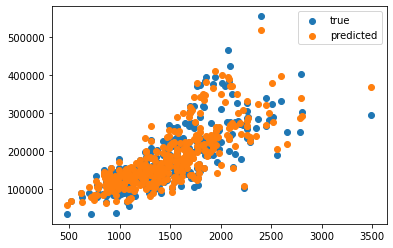

In [116]:
plt.scatter(X_subtest["GrLivArea"], y_subtest, label="true")
plt.scatter(X_subtest["GrLivArea"], xgb_model.predict(X_subtest), label="predicted")
plt.legend(loc='best')
plt.show()

In [127]:
xgb_model = xgb.XGBRegressor(learning_rate=0.1, max_depth=3, min_child_weight=3,
                             n_estimators=1000, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

submission = pd.DataFrame({'Id': X_test.index, 'SalePrice': xgb_model.predict(X_test)})
submission.to_csv("submission.csv", index=False)

In [130]:
!kaggle competitions submit -c house-prices-advanced-regression-techniques -f submission.csv -m "Message"

Successfully submitted to House Prices - Advanced Regression Techniques



  0%|          | 0.00/22.6k [00:00<?, ?B/s]
100%|##########| 22.6k/22.6k [00:02<00:00, 9.60kB/s]
